In [295]:
!which python
%load_ext autoreload
%autoreload 2


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/bin/python
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [296]:
#If there are issues with importing modules. This is for reloading a module
import importlib
import computations_funcs
import plot_funcs
import data_collection
modules=[computations_funcs,plot_funcs,data_collection]
for module in modules:
    importlib.reload(module)

In [297]:
import ee
from dotenv import load_dotenv
import os
from data_collection import get_state_districs,get_region_for_districts,generate_mask_for_region,get_data_for_districts
import numpy as np
import matplotlib.pyplot as plt
from computations_funcs import smooth_stack_from_array_dict , resize_img ,generate_probability_mask,convert_smooth_data_to_bins,create_balanced_csv
from data_initialization import categorical_labels,band_cmaps,mcdm_weights
from plot_funcs import plot_bands_one_by_one,visualize_distribution
import matplotlib.colors as mcolors



load_dotenv()

PROJECT_NAME = os.getenv("PROJECT_NAME")
if PROJECT_NAME is None:
    raise Exception("Please set the PROJECT_NAME environment variable")

In [265]:
print('Initializing Earth Engine')
try:
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
except Exception as e:
    print('Initializing Earth Engine for the first time')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
# NOTE: This is a test to check if ee is initialized
# image = ee.Image('USGS/SRTMGL1_003')
# print(image.getInfo())

Initializing Earth Engine
Successfully initialized Earth Engine Project be-project-aaronfurtado2003


In [266]:
state=''
while(state==''):
    state=input("Please Enter a state name:")

state_source,districts=get_state_districs(state)
print(f'List of Districts in {state} are:\n{districts}')
print('\n')
selected_districts_unfiltered=input("Please Enter the name of the Districts separated by comma:\n")
selected_districts=selected_districts_unfiltered.split(',')
selected_districts=[district.strip() for district in selected_districts]

print(f'Selected Districts are:\n{selected_districts}')

List of Districts in Maharashtra are:
['Nandurbar', 'Akola', 'Amravati', 'Bhandara', 'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Jalgaon', 'Kolhapur', 'Latur', 'Nagpur', 'Nanded', 'Nashik', 'Osmanabad', 'Pune', 'Raigarh', 'Ratnagiri', 'Sindhudurg', 'Sangli', 'Satara', 'Solapur', 'Thane', 'Wardha', 'Yavatmal', 'Aurangabad', 'Ahmednagar', 'Bid', 'Gondiya', 'Hingoli', 'Jalna', 'Mumbai Suburban', 'Mumbai city', 'Parbhani', 'Washim']


Selected Districts are:
['Aurangabad', 'Bid', 'Hingoli', 'Latur', 'Osmanabad', 'Jalna', 'Parbhani', 'Nanded']


In [267]:
print(f'Getting region scale and boundary for districts')
region,scale,region_self_mask=get_region_for_districts(state_source,selected_districts)

print(f'Generating masks for selected region')
mask_projection,region_mask=generate_mask_for_region(region,scale)
mask_value=999999
print(f'Collecting data for {selected_districts}')
array_dict=get_data_for_districts(region,scale,mask_projection,region_self_mask,mask_value)

Getting region scale and boundary for districts
Generating masks for selected region


In [268]:
print(f'Array Dict Keys: {array_dict.keys()}')
for key,arr in array_dict['properties'].items():
    arr=np.array(arr)
    arr= np.ma.masked_equal(arr, mask_value)
    print(f'{key}: {arr.shape} min: {np.nanmin(arr)} max: {np.nanmax(arr)} avg: {np.nanmean(arr)}')


Array Dict Keys: dict_keys(['properties'])
dem: (289, 342) min: 235 max: 911 avg: 524.0745804847732
dist_to_water: (289, 342) min: 0.0 max: 116.86744627996283 avg: 43.885043821556216
flow_acc: (289, 342) min: 233.3234405517578 max: 918.3499755859375 avg: 523.3023269559404
geom: (289, 342) min: 11 max: 42 avg: 29.204595120190863
lulc: (289, 342) min: 10 max: 80 avg: 39.45608372260871
ndwi: (289, 342) min: -0.3941887319087982 max: 0.3646794855594635 avg: -0.25107219933240577
rain: (289, 342) min: 1.8095508813858032 max: 4.068039894104004 avg: 2.8480007452394918
runoff_coeff: (289, 342) min: 3.3 max: 27.265797448158263 avg: 12.522057695329844
slope: (289, 342) min: 0.0 max: 13.396930694580078 avg: 0.6105082191582307
soilTx: (289, 342) min: 1 max: 10 avg: 1.470097636279797
soil_moisture: (289, 342) min: 6.466616153717041 max: 11.455821990966797 avg: 9.851076208036348


In [269]:
print(f'Resizing and smoothing collected data')
smoothed_stack,band_names=smooth_stack_from_array_dict(array_dict,categorical_bands=categorical_labels.keys())
print(f'Stack shape: {smoothed_stack.shape}')
print(f'Band names: {band_names}')

Resizing and smoothing collected data
[INFO] Band 'dem' replacing 3828 NaNs with 0.0
[INFO] Band 'dist_to_water' replacing 3828 NaNs with 0.0
[INFO] Band 'flow_acc' replacing 3828 NaNs with 0.0
[INFO] Band 'ndwi' replacing 3828 NaNs with -0.38250105816623897
[INFO] Band 'rain' replacing 3828 NaNs with 0.0
[INFO] Band 'runoff_coeff' replacing 3828 NaNs with 0.0
[INFO] Band 'slope' replacing 3828 NaNs with 0.0
[INFO] Band 'soil_moisture' replacing 3828 NaNs with 0.0
Stack shape: (512, 605, 11)
Band names: ['dem', 'dist_to_water', 'flow_acc', 'geom', 'lulc', 'ndwi', 'rain', 'runoff_coeff', 'slope', 'soilTx', 'soil_moisture']


Visualizing distribution of collected data
number of pixels of data 309760
number of pixels of flat data 157277


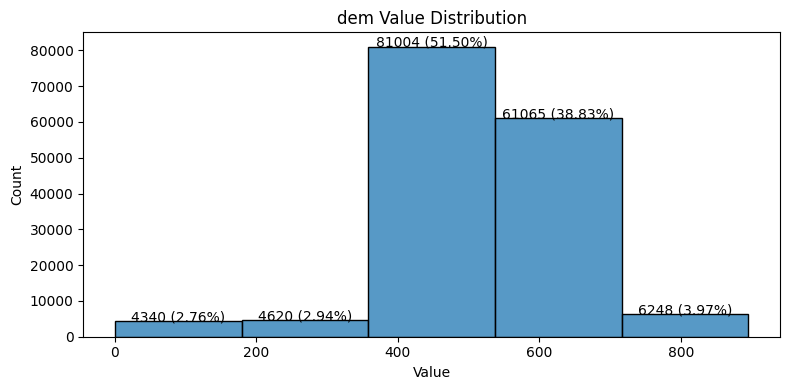

number of pixels of data 309760
number of pixels of flat data 157277


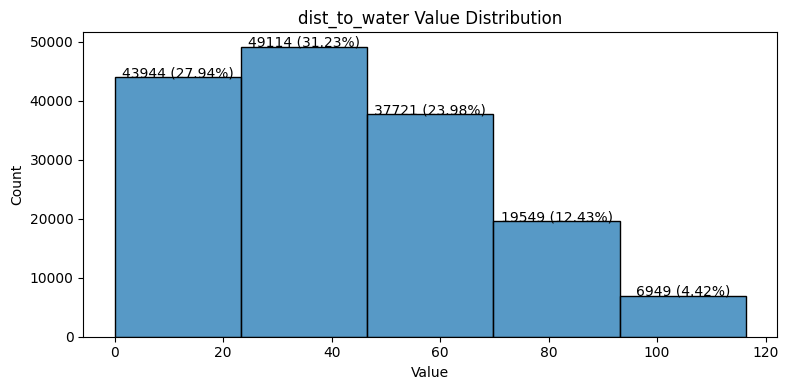

number of pixels of data 309760
number of pixels of flat data 157277


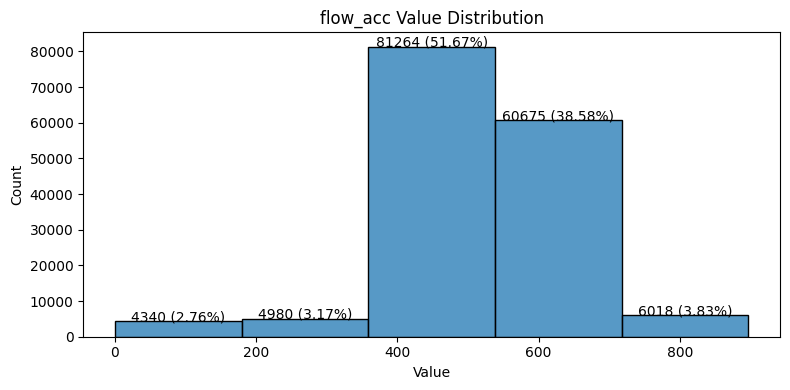

number of pixels of data 309760
number of pixels of flat data 157277


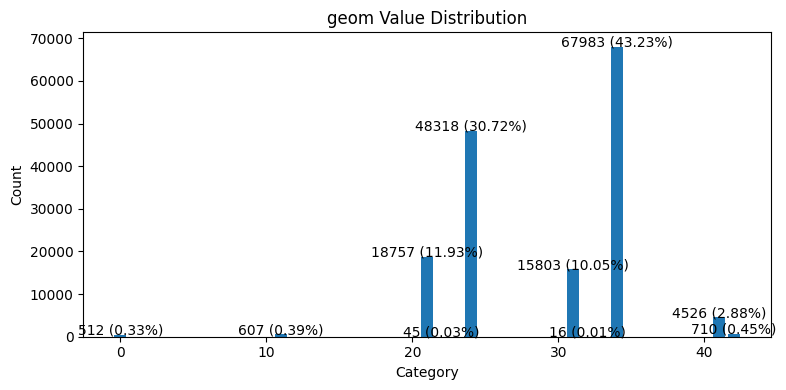

number of pixels of data 309760
number of pixels of flat data 157277


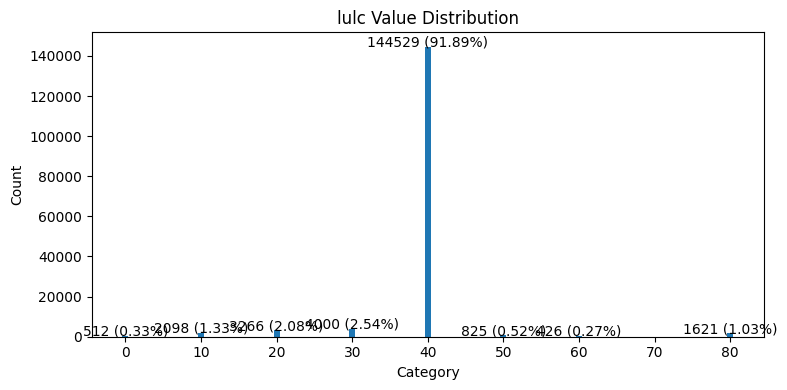

number of pixels of data 309760
number of pixels of flat data 157277


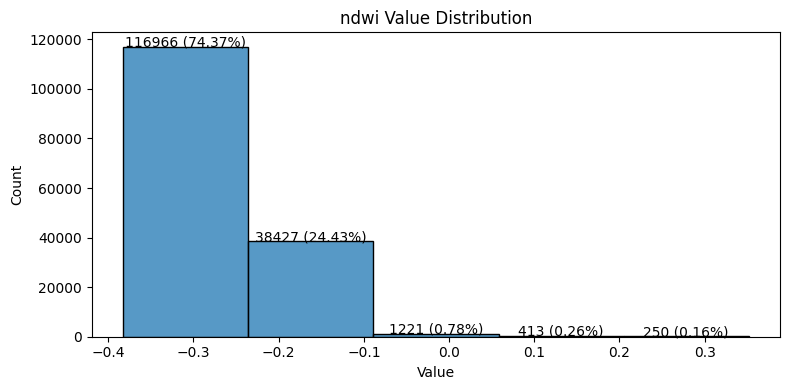

number of pixels of data 309760
number of pixels of flat data 157277


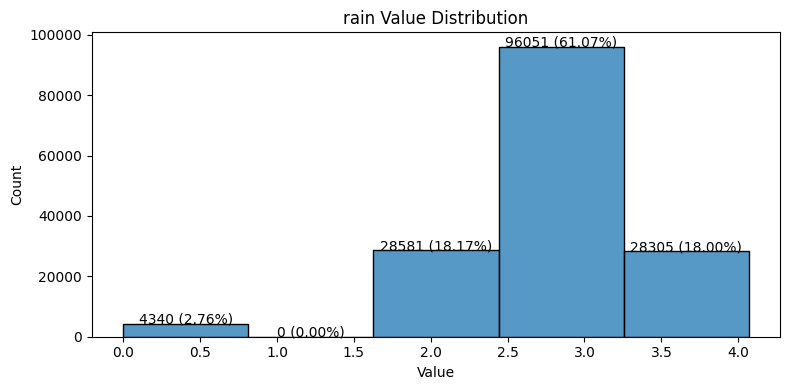

number of pixels of data 309760
number of pixels of flat data 157277


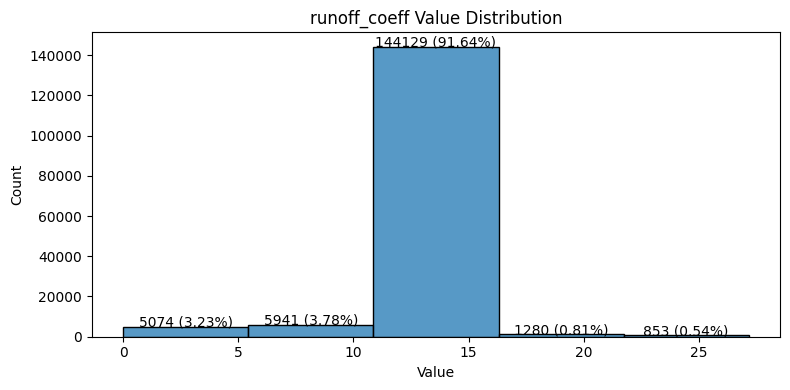

number of pixels of data 309760
number of pixels of flat data 157277


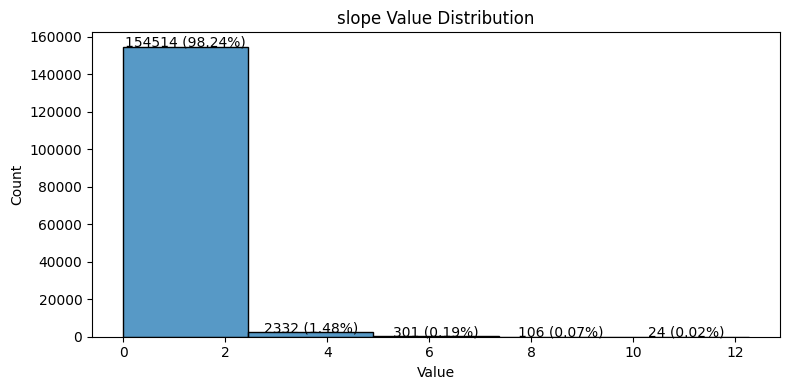

number of pixels of data 309760
number of pixels of flat data 157277


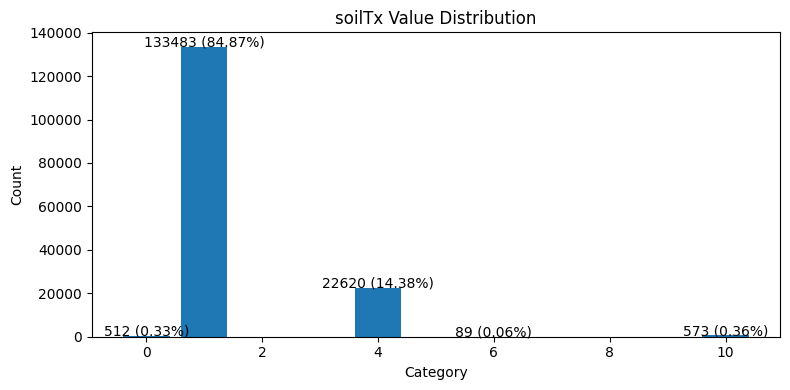

number of pixels of data 309760
number of pixels of flat data 157277


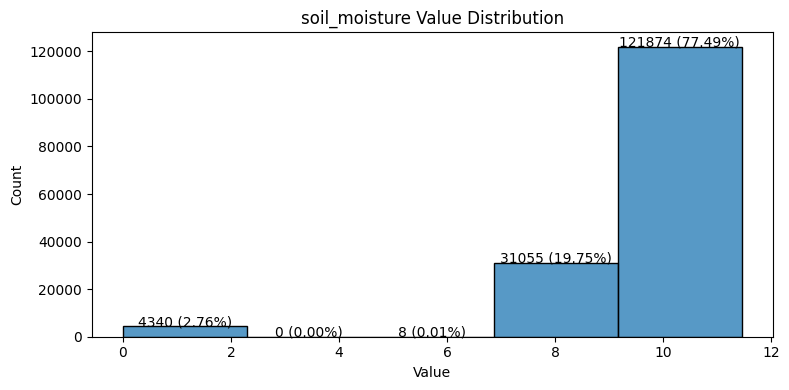

In [270]:
bins=input('Enter the number of bins you want to use for the continous data:')
print(f'Visualizing distribution of collected data')
visualize_distribution(smoothed_stack,band_names,categorical_bands=categorical_labels.keys(),bins=int(bins))

In [271]:
method=input('Enter the method you want to use to convert continous data into bins (kmeans/quantile).Press Enter for Default:')
if method=='':
    print('Defaulting to kmeans')
    method='kmeans'
print(f'Converting continous data into bins using kmeans')
tiers,breaks=convert_smooth_data_to_bins(smoothed_stack,band_names,n_classes=5,method=method)


Defaulting to kmeans
Converting continous data into bins using kmeans


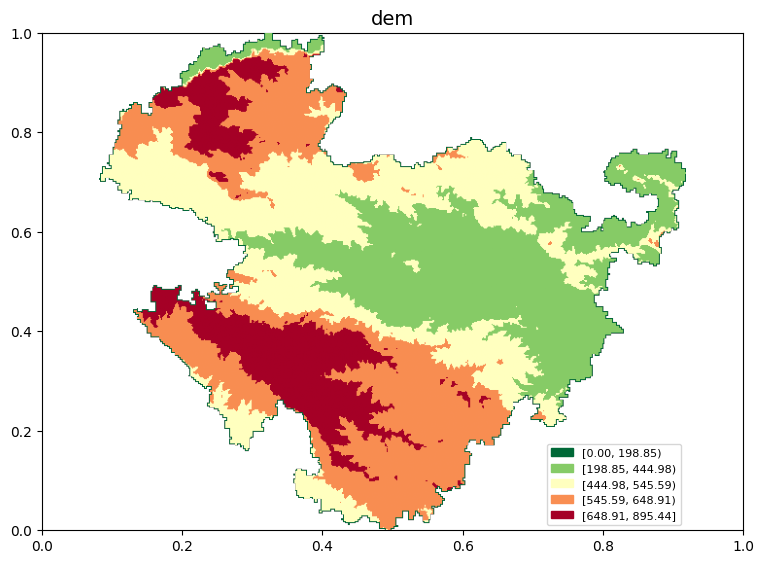

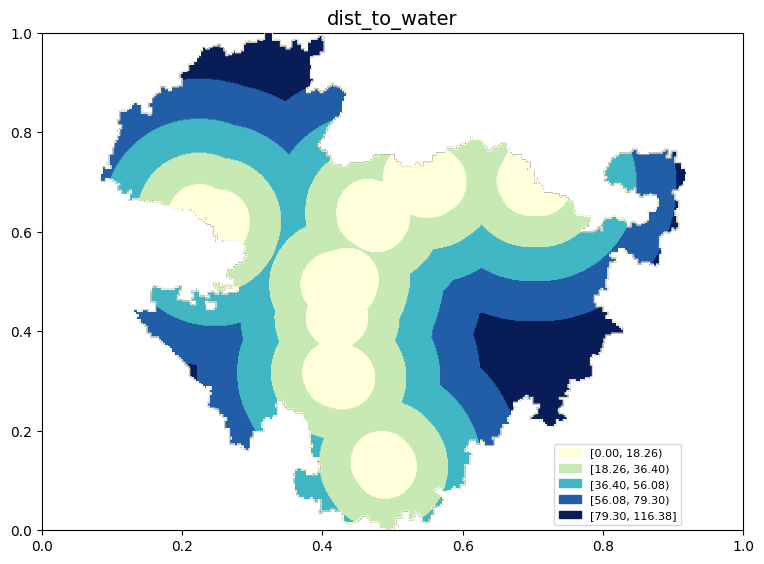

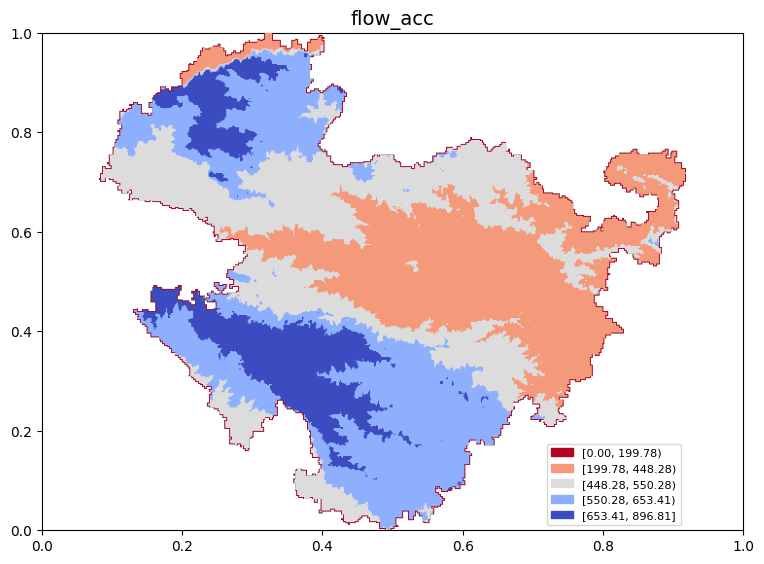

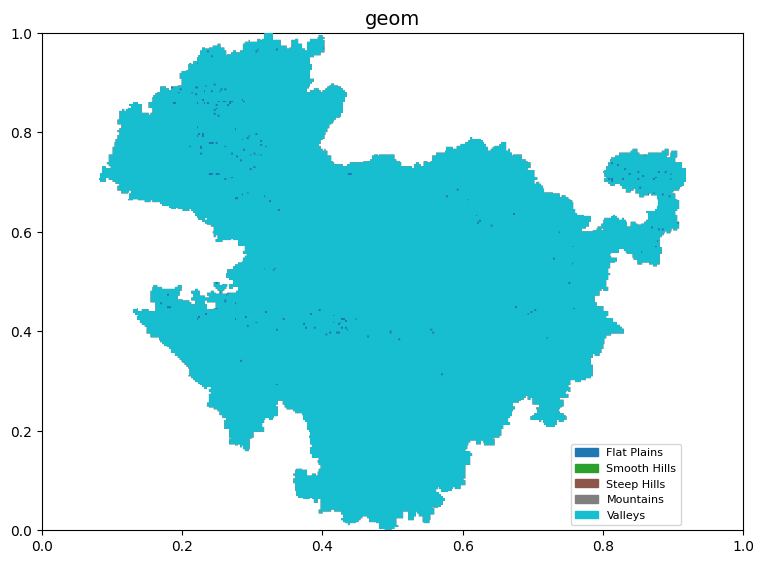

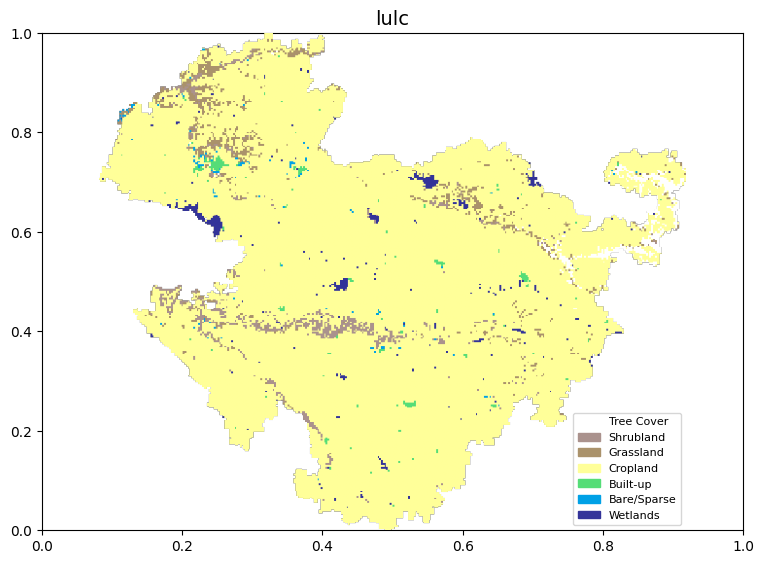

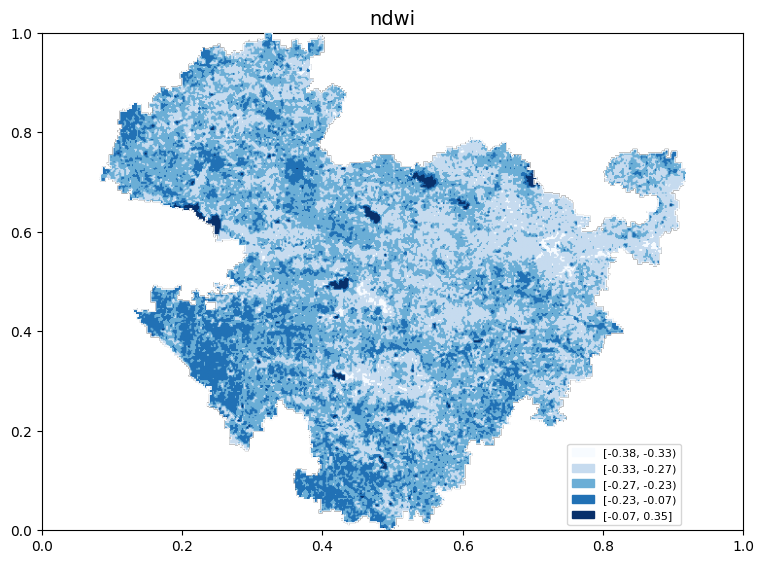

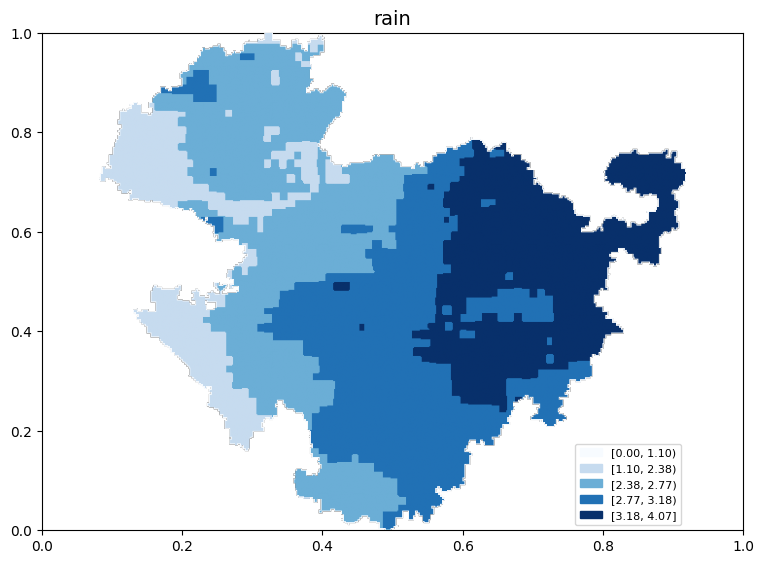

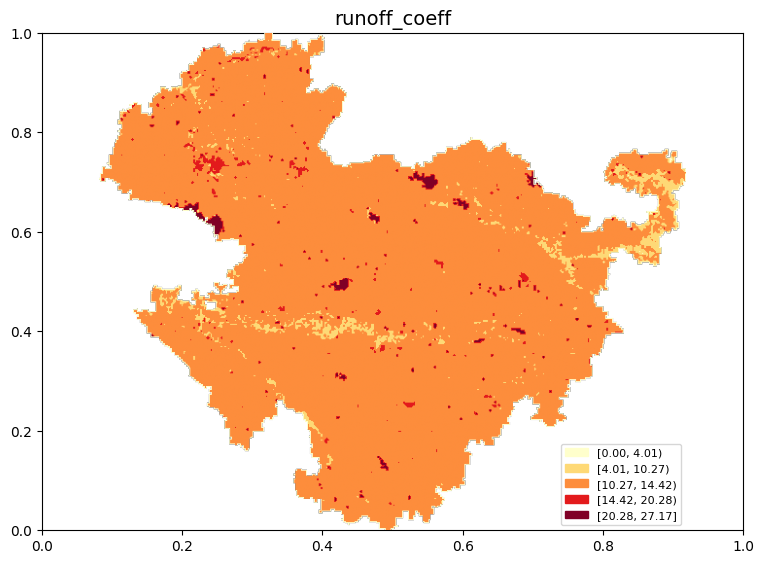

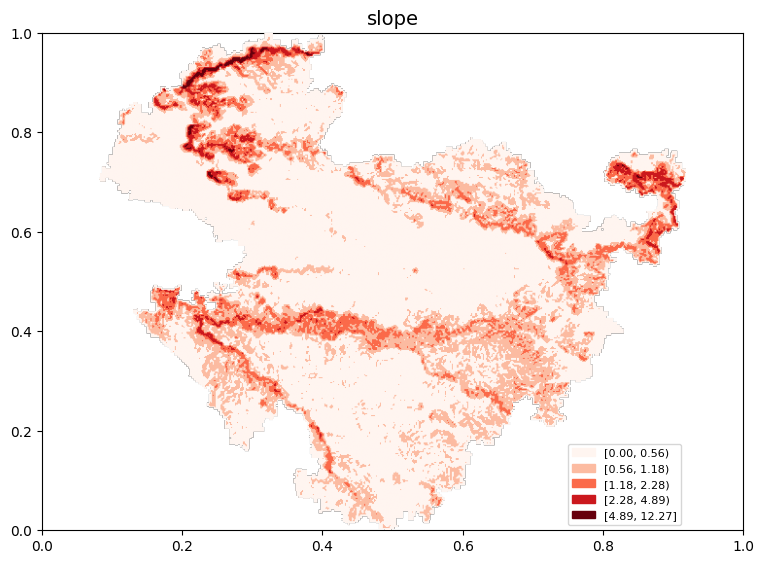

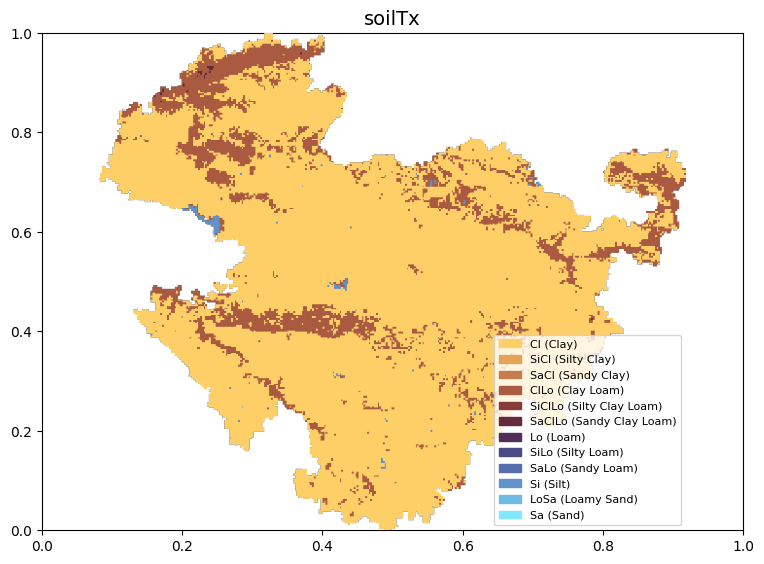

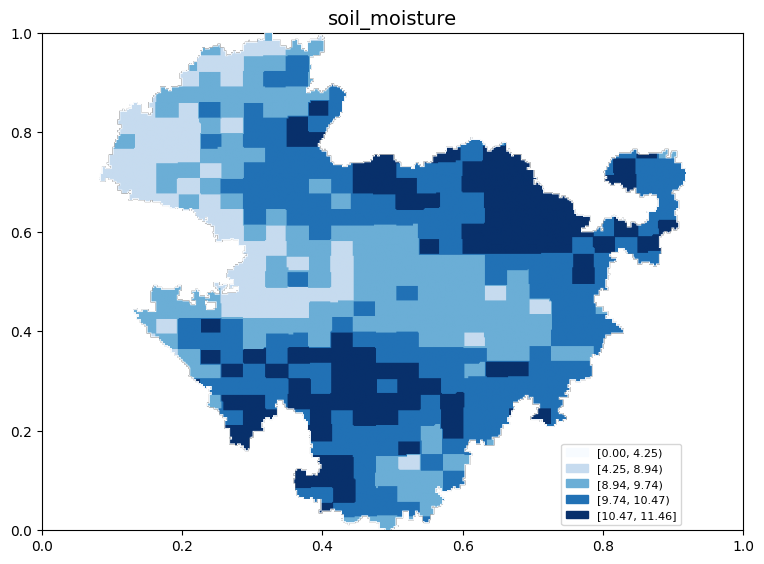

In [298]:
plot_choice=''
while(plot_choice.lower() not in ['y','n']):
    plot_choice=input("Do you want to plot the data? (y/n):")
    if plot_choice.lower()=='y':
        plot_bands_one_by_one(
            smoothed_stack=tiers,
            band_names=band_names,
            region_mask=resize_img(region_mask)
            ,band_cmaps=band_cmaps,
            categorical_labels=categorical_labels,
            breaks=breaks
            )
    else:
        print('No problem!')

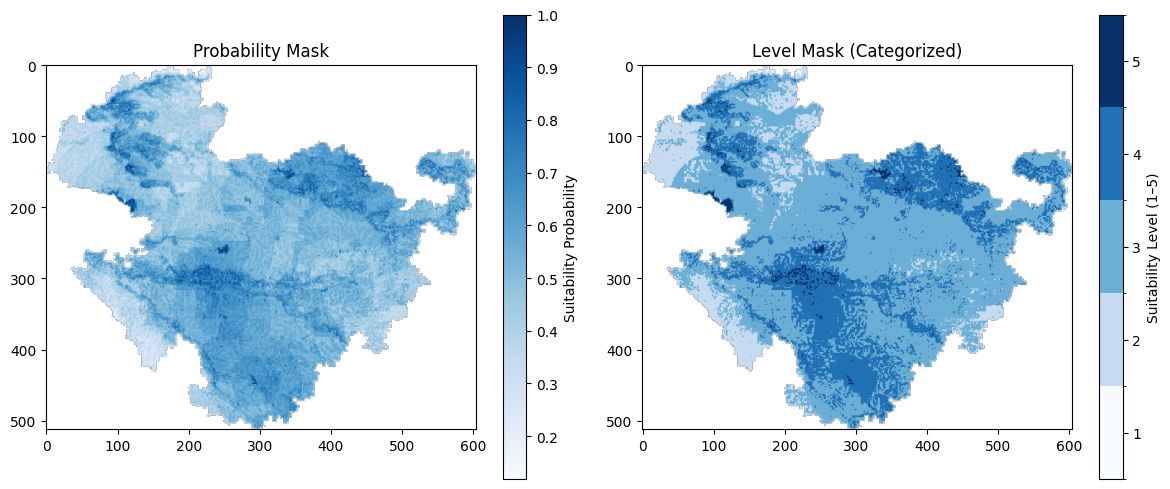

In [283]:
prob_mask, level_mask, weighted_sum  = generate_probability_mask(data=[x for x in tiers.values()],band_names=band_names,weights=mcdm_weights)
masked_prob = (np.where(resize_img(region_mask) == 1, prob_mask, np.nan))
masked_level =( np.where(resize_img(region_mask) == 1, level_mask, np.nan))
plt.figure(figsize=(12, 5))

# Plot probability mask
plt.subplot(1, 2, 1)
plt.imshow(masked_prob, cmap='Blues')
plt.colorbar(label='Suitability Probability')
plt.title('Probability Mask')

# Plot level mask
plt.subplot(1, 2, 2)
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ncolors=5)
im = plt.imshow(masked_level, plt.get_cmap('Blues', 5), norm=norm)
cbar = plt.colorbar(im, ticks=[1, 2, 3, 4, 5])
cbar.set_label('Suitability Level (1–5)')
plt.title('Level Mask (Categorized)')
plt.tight_layout()
plt.show()

In [284]:
name=input('Enter a file name:\n')
transposed_tiers=np.transpose(np.array([np.array(x) for x in tiers.values()]),(1,2,0))
dataset=create_balanced_csv(smoothed_stack,resize_img(level_mask),resize_img(prob_mask),band_names,resize_img(region_mask),3000,23,name=f'continous_{name}_dataset')
dataset2=create_balanced_csv(transposed_tiers,resize_img(level_mask),resize_img(prob_mask),band_names,resize_img(region_mask),3000,23,name=f'transposed_{name}_dataset')

Valid flat_level:[1 2 3 4 5 6]
(156765, 11)
⚠️ Not enough samples for level 1. Found: 252
✅ Saved to 'continous_marathwada_dataset.csv'
Valid flat_level:[1 2 3 4 5 6]
(156765, 11)
⚠️ Not enough samples for level 1. Found: 252
✅ Saved to 'transposed_marathwada_dataset.csv'


**Debug**

In [277]:
np.unique(weighted_sum,return_counts=True)

(array([-0.05178571, -0.04880953, -0.04583335, ...,  0.9982143 ,
         1.0357143 ,  1.0565476 ], shape=(1212,), dtype=float32),
 array([  1, 344,   7, ...,   2,   1,  49], shape=(1212,)))

In [278]:
for band in tiers.keys():
    print(band)
    print(np.unique(tiers[band],return_counts=True))
# for band in array_dict['properties'].keys():
#     print(band)
#     print(np.unique(array_dict['properties'][band],return_counts=True))

dem
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([  4340,  43330,  45393,  42738,  21476, 152483]))
dist_to_water
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([ 32248,  41902,  35011,  32123,  15993, 152483]))
flow_acc
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([  4340,  45266,  45449,  42579,  19643, 152483]))
geom
(array([ 0., 11., 21., 22., 24., 31., 32., 34., 41., 42., nan]), array([   512,    607,  18757,     45,  48318,  15803,     16,  67983,
         4526,    710, 152483]))
lulc
(array([ 0., 10., 20., 30., 40., 50., 60., 80., nan]), array([   512,   2098,   3266,   4000, 144529,    825,    426,   1621,
       152483]))
ndwi
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([  5209,  52243,  72414,  25653,   1758, 152483]))
rain
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([  4340,  19683,  47987,  47389,  37878, 152483]))
runoff_coeff
(array([ 1.,  2.,  3.,  4.,  5., nan]), array([  4364,   5182, 143909,   2790,   1032, 152483]))
slope
(array([ 1.,  2.,  3.,  4.,  5., nan]), 

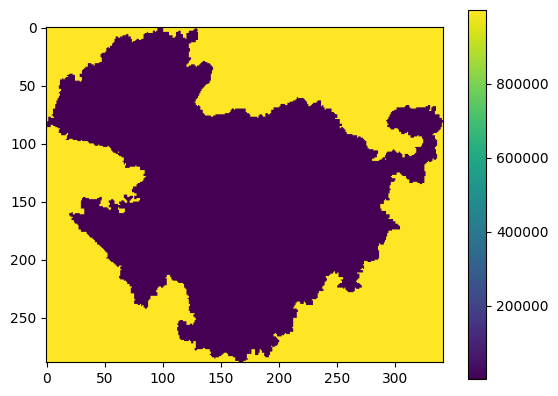

In [279]:
plt.imshow(array_dict['properties']['soilTx'])
plt.colorbar()
plt.show()